# **RIDGE regression**

Marek Šugár

Here we evaluated the near-optimal settings for the model in terms of the best performing <code>MAPE</code>. We have implemented sequential grid search for <code>Training Window</code> length and $\lambda$ regularization parameter.

Particular stocks included in this analysis were **TOP 2** and **BOTTOM 2** stocks in terms of <code>MAPE</code> in the very first model created with default regularization parameter and **Training Window** length 8.

We include heat-map visuals to better comprehend the behaviour observed.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ML Stuff
from sklearn.linear_model import Ridge

# In case of convergence problem, supress warning
import warnings

#warnings.filterwarnings("ignore")

In [2]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

# **RIDGE regression**

In [ ]:
performance_trackerENPH = {}

for Alpha in [0.0001, 0.01, 0.1, 1, 10, 100]:
    for window_length in range(2, 31):
        for ticker in ["ENPH"]:
            Stock_Data = pd.read_sql(
                f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
                con=StockDataDatabase, parse_dates=["Date"]
            )
            
            Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
            Stock_Data["Target"] = Stock_Data["Close"]
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            training_length = window_length
            prediction_length = 1

            MAPEs = []

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                # Define feature and target windows
                Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

                Test_Features = Stock_Data[historic_columns].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]
                Test_Target = Stock_Data["Target"].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]

                # Skip empty slices
                if Training_Features.empty or Test_Features.empty:
                    continue
            
                # Scale only selected features
                scaler = StandardScaler()
                Training_Features = scaler.fit_transform(Training_Features)
                Test_Features = scaler.transform(Test_Features)

                # Fit KNN
                MODEL = Ridge(alpha=Alpha)
                MODEL.fit(Training_Features, Training_Target)

                # Predict and evaluate
                prediction = MODEL.predict(Test_Features)
                MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
            # Save results
            performance_trackerENPH[(Alpha, window_length)] = np.mean(MAPEs)
            print((Alpha, window_length), np.mean(MAPEs))


<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hd/lvkyz8053vg15hx2z_h9tsnh0000gn/T/ipykernel_1292/4239538046.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$\lambda$ regularization")


Text(50.722222222222214, 0.5, '$\\lambda$ regularization')

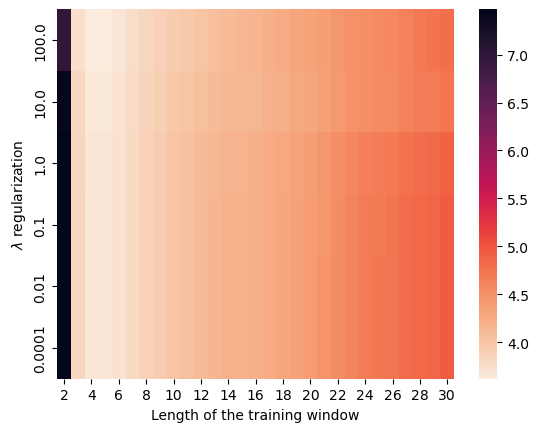

In [7]:
df = pd.Series(performance_trackerENPH).unstack()

sns.heatmap(df, cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of the training window")
plt.ylabel("$\lambda$ regularization")

In [8]:
np.argmin(list(performance_trackerENPH.values()))

np.int64(147)

In [9]:
performance_trackerROP = {}

for Alpha in [0.0001, 0.01, 0.1, 1, 10, 100]:#np.logspace(-4, 2, 50):
    for window_length in range(2, 31):
        for ticker in ["ROP"]:
            Stock_Data = pd.read_sql(
                f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
                con=StockDataDatabase, parse_dates=["Date"]
            )
            
            Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
            Stock_Data["Target"] = Stock_Data["Close"]
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            training_length = window_length
            prediction_length = 1

            MAPEs = []

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                # Define feature and target windows
                Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

                Test_Features = Stock_Data[historic_columns].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]
                Test_Target = Stock_Data["Target"].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]

                # Skip empty slices
                if Training_Features.empty or Test_Features.empty:
                    continue
            
                # Scale only selected features
                scaler = StandardScaler()
                Training_Features = scaler.fit_transform(Training_Features)
                Test_Features = scaler.transform(Test_Features)

                # Fit KNN
                MODEL = Ridge(alpha=Alpha)
                MODEL.fit(Training_Features, Training_Target)

                # Predict and evaluate
                prediction = MODEL.predict(Test_Features)
                MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
            # Save results
            performance_trackerROP[(Alpha, window_length)] = np.mean(MAPEs)
            print((Alpha, window_length), np.mean(MAPEs))


(0.0001, 2) 2.3888574703410956
(0.0001, 3) 1.1728546578309513
(0.0001, 4) 1.1094679075112046
(0.0001, 5) 1.110110917136313
(0.0001, 6) 1.1197522490616123
(0.0001, 7) 1.1393536643013262
(0.0001, 8) 1.1550424086231001
(0.0001, 9) 1.173358327362257
(0.0001, 10) 1.1976711396846311
(0.0001, 11) 1.203958960453443
(0.0001, 12) 1.2089069226508407
(0.0001, 13) 1.2259530241281955
(0.0001, 14) 1.239615031840797
(0.0001, 15) 1.2510328270925184
(0.0001, 16) 1.260811649153281
(0.0001, 17) 1.2689263498511825
(0.0001, 18) 1.2826620809318046
(0.0001, 19) 1.2927053017224208
(0.0001, 20) 1.3089952947325936
(0.0001, 21) 1.327062748340408
(0.0001, 22) 1.3309799585927764
(0.0001, 23) 1.3451036033810932
(0.0001, 24) 1.3619678304750187
(0.0001, 25) 1.3669619838277212
(0.0001, 26) 1.381535198744778
(0.0001, 27) 1.3870217083953822
(0.0001, 28) 1.3919715203412824
(0.0001, 29) 1.3955218034423587
(0.0001, 30) 1.3931865211932142
(0.01, 2) 2.3888391859910216
(0.01, 3) 1.172850665926273
(0.01, 4) 1.1094645762023925
(

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hd/lvkyz8053vg15hx2z_h9tsnh0000gn/T/ipykernel_1292/508553450.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$\lambda$ regularization")


Text(50.722222222222214, 0.5, '$\\lambda$ regularization')

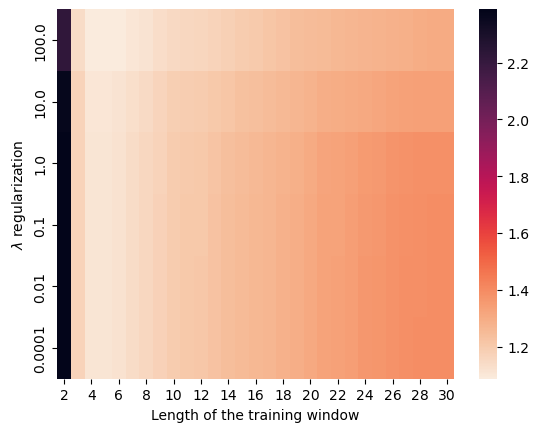

In [10]:
df = pd.Series(performance_trackerROP).unstack()

sns.heatmap(df, cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of the training window")
plt.ylabel("$\lambda$ regularization")

In [11]:
np.argmin(list(performance_trackerROP.values()))

np.int64(148)

In [12]:
performance_trackerSMCI = {}

for Alpha in [0.0001, 0.01, 0.1, 1, 10, 100]:#np.logspace(-4, 2, 50):
    for window_length in range(2, 31):
        for ticker in ["SMCI"]:
            Stock_Data = pd.read_sql(
                f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
                con=StockDataDatabase, parse_dates=["Date"]
            )
            
            Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
            Stock_Data["Target"] = Stock_Data["Close"]
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            training_length = window_length
            prediction_length = 1

            MAPEs = []

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                # Define feature and target windows
                Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

                Test_Features = Stock_Data[historic_columns].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]
                Test_Target = Stock_Data["Target"].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]

                # Skip empty slices
                if Training_Features.empty or Test_Features.empty:
                    continue
            
                # Scale only selected features
                scaler = StandardScaler()
                Training_Features = scaler.fit_transform(Training_Features)
                Test_Features = scaler.transform(Test_Features)

                # Fit KNN
                MODEL = Ridge(alpha=Alpha)
                MODEL.fit(Training_Features, Training_Target)

                # Predict and evaluate
                prediction = MODEL.predict(Test_Features)
                MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
            # Save results
            performance_trackerSMCI[(Alpha, window_length)] = np.mean(MAPEs)
            print((Alpha, window_length), np.mean(MAPEs))


(0.0001, 2) 6.054523775254048
(0.0001, 3) 3.1744923043805615
(0.0001, 4) 3.0192484590833257
(0.0001, 5) 3.067771801609453
(0.0001, 6) 3.1058276367183173
(0.0001, 7) 3.1797233186088842
(0.0001, 8) 3.240007307843392
(0.0001, 9) 3.3095691520539323
(0.0001, 10) 3.4020213293475736
(0.0001, 11) 3.4432770785767994
(0.0001, 12) 3.504013445970579
(0.0001, 13) 3.6163656803285558
(0.0001, 14) 3.625720151053595
(0.0001, 15) 3.6437208656628215
(0.0001, 16) 3.6904709491215604
(0.0001, 17) 3.702957277574957
(0.0001, 18) 3.7248317764106416
(0.0001, 19) 3.7974194890337745
(0.0001, 20) 3.8244703082022444
(0.0001, 21) 3.862662941361357
(0.0001, 22) 3.8980343251491414
(0.0001, 23) 3.906704660779758
(0.0001, 24) 3.9492546405820446
(0.0001, 25) 3.9626032500188497
(0.0001, 26) 4.001775557478208
(0.0001, 27) 4.0591524771236545
(0.0001, 28) 4.099114894237333
(0.0001, 29) 4.128580582718861
(0.0001, 30) 4.1299708554512335
(0.01, 2) 6.054479786252661
(0.01, 3) 3.174482442831202
(0.01, 4) 3.0192395107771866
(0.01,

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hd/lvkyz8053vg15hx2z_h9tsnh0000gn/T/ipykernel_1292/2340393621.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$\lambda$ regularization")


Text(50.722222222222214, 0.5, '$\\lambda$ regularization')

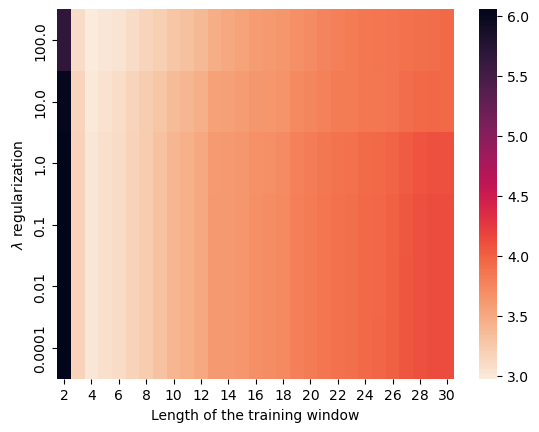

In [13]:
df = pd.Series(performance_trackerSMCI).unstack()

sns.heatmap(df, cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of the training window")
plt.ylabel("$\lambda$ regularization")

In [14]:
np.argmin(list(performance_trackerSMCI.values()))

np.int64(147)

In [15]:
performance_trackerMSI = {}

for Alpha in [0.0001, 0.01, 0.1, 1, 10, 100]:#np.logspace(-4, 2, 50):
    for window_length in range(2, 31):
        for ticker in ["MSI"]:
            Stock_Data = pd.read_sql(
                f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
                con=StockDataDatabase, parse_dates=["Date"]
            )
            
            Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
            Stock_Data["Target"] = Stock_Data["Close"]
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            training_length = window_length
            prediction_length = 1

            MAPEs = []

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                # Define feature and target windows
                Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

                Test_Features = Stock_Data[historic_columns].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]
                Test_Target = Stock_Data["Target"].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]

                # Skip empty slices
                if Training_Features.empty or Test_Features.empty:
                    continue
            
                # Scale only selected features
                scaler = StandardScaler()
                Training_Features = scaler.fit_transform(Training_Features)
                Test_Features = scaler.transform(Test_Features)

                # Fit KNN
                MODEL = Ridge(alpha=Alpha)
                MODEL.fit(Training_Features, Training_Target)

                # Predict and evaluate
                prediction = MODEL.predict(Test_Features)
                MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
            # Save results
            performance_trackerMSI[(Alpha, window_length)] = np.mean(MAPEs)
            print((Alpha, window_length), np.mean(MAPEs))


(0.0001, 2) 2.554911675116331
(0.0001, 3) 1.269183360685145
(0.0001, 4) 1.2095117854262265
(0.0001, 5) 1.2000261413656599
(0.0001, 6) 1.204138232846771
(0.0001, 7) 1.2250502103136285
(0.0001, 8) 1.2451810193624941
(0.0001, 9) 1.2659121762093026
(0.0001, 10) 1.2669472278512435
(0.0001, 11) 1.2891816687299587
(0.0001, 12) 1.2924567815577805
(0.0001, 13) 1.3007943590778523
(0.0001, 14) 1.3120385896501314
(0.0001, 15) 1.3106603547071989
(0.0001, 16) 1.328609665191965
(0.0001, 17) 1.3462375069914283
(0.0001, 18) 1.3550998809651238
(0.0001, 19) 1.367010034185982
(0.0001, 20) 1.3803190041290678
(0.0001, 21) 1.4047490381683005
(0.0001, 22) 1.421747154869126
(0.0001, 23) 1.441669600697057
(0.0001, 24) 1.4572341161186728
(0.0001, 25) 1.4693263674839259
(0.0001, 26) 1.4846771747378593
(0.0001, 27) 1.5012170465380739
(0.0001, 28) 1.5143706054344095
(0.0001, 29) 1.5202434934708706
(0.0001, 30) 1.5235251070439588
(0.01, 2) 2.5548923925518134
(0.01, 3) 1.2691784867631213
(0.01, 4) 1.2095069635885867


<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hd/lvkyz8053vg15hx2z_h9tsnh0000gn/T/ipykernel_1292/2595922068.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$\lambda$ regularization")


Text(50.722222222222214, 0.5, '$\\lambda$ regularization')

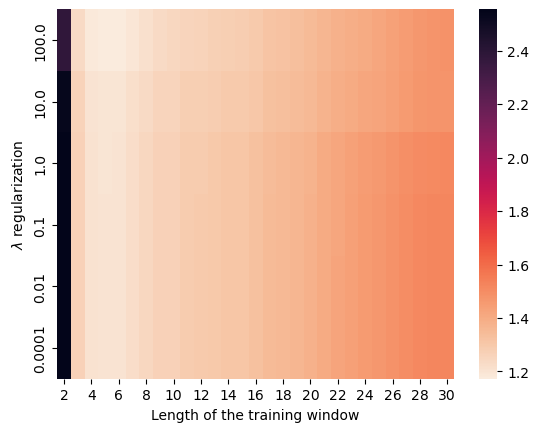

In [16]:
df = pd.Series(performance_trackerMSI).unstack()

sns.heatmap(df, cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of the training window")
plt.ylabel("$\lambda$ regularization")

In [20]:
print(np.argmin(list(performance_trackerENPH.values())))
print(np.argmin(list(performance_trackerSMCI.values())))
print(np.argmin(list(performance_trackerROP.values())))
print(np.argmin(list(performance_trackerMSI.values())))

# V oboch prípadoch dostávame argmin hodnoty
# 147 -> (100, 4)
# 148 -> (100, 5)
# Vykonáme validáciu a porovnáme priemernú odchýlku pre obe
# dvojice parameterov 

list(performance_trackerROP.keys())[148]

147
147
148
148


(100, 5)

# Analysis of certain $\lambda$

We perform in-depth analysis of regularization parameter for the fixed, experimentally derived near-optimal training window length.

In [4]:
performance_trackerENPH_regularization = {}

for Alpha in range(10, 1000, 10):#np.logspace(-4, 2, 50):
    for ticker in ["SMCI"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
            
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 4
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue
            
            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features)
            Test_Features = scaler.transform(Test_Features)

            # Fit KNN
            MODEL = Ridge(alpha=Alpha)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
        # Save results
        performance_trackerENPH_regularization[Alpha] = np.mean(MAPEs)
        print(Alpha, np.mean(MAPEs), np.sum(MODEL.coef_ != 0))


10 3.0108820516932107 450
20 3.003683373991964 450
30 2.997788385649165 450
40 2.9926143116270665 450
50 2.9879728731698014 450
60 2.984058554288223 450
70 2.9807924629984126 450
80 2.978494831687195 450
90 2.9773562491342673 450
100 2.976638137191245 450
110 2.9762470646600567 450
120 2.9762558191533253 450
130 2.9764860558028374 450
140 2.977168400865218 450
150 2.9782647784604506 450
160 2.979789628852543 450
170 2.9814999154962787 450
180 2.983460479606289 450
190 2.9855088253747613 450
200 2.9876549464252142 450
210 2.9898859230169386 450
220 2.9921799411178736 450
230 2.994571551661261 450
240 2.9970325474131942 450
250 2.9995397031904845 450
260 3.0021827924726048 450
270 3.0048964275329864 450
280 3.00780333917858 450
290 3.0108601893321665 450
300 3.014026113729299 450
310 3.0173360147731407 450
320 3.020656767932389 450
330 3.024134056327918 450
340 3.027714767511693 450
350 3.0313620692175576 450
360 3.03512924167042 450
370 3.038883980851511 450
380 3.0426888671074264 450
3

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hd/lvkyz8053vg15hx2z_h9tsnh0000gn/T/ipykernel_4988/3755794406.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$ regularization")


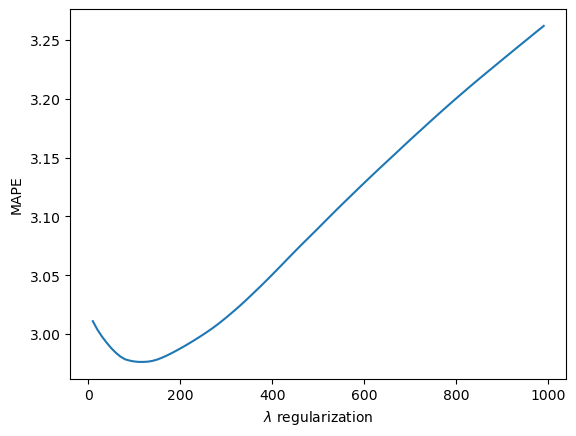

In [8]:
plt.plot(performance_trackerENPH_regularization.keys(), performance_trackerENPH_regularization.values())

plt.xlabel("$\lambda$ regularization")
plt.ylabel("MAPE")

plt.show()

In [9]:
performance_trackerROP_regularization = {}

for Alpha in range(10, 1000, 10):#np.logspace(-4, 2, 50):
    for ticker in ["ROP"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
            
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 4
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue
            
            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features)
            Test_Features = scaler.transform(Test_Features)

            # Fit KNN
            MODEL = Ridge(alpha=Alpha)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
        # Save results
        performance_trackerROP_regularization[Alpha] = np.mean(MAPEs)
        print(Alpha, np.mean(MAPEs), np.sum(MODEL.coef_ != 0))


10 1.1062714750664888 450
20 1.1034481974883095 450
30 1.1008890153593587 450
40 1.0986079729653335 450
50 1.0966215015227978 450
60 1.094868455435153 450
70 1.0933110340376975 450
80 1.0919355589217046 450
90 1.0906896229759517 450
100 1.08961308921466 450
110 1.0886248297248888 450
120 1.0877303515025203 450
130 1.0869289799974884 450
140 1.0862367025502473 450
150 1.0856363637265005 450
160 1.085127696642628 450
170 1.08471412794583 450
180 1.0843860946734145 450
190 1.084152190048422 450
200 1.0840113796598432 450
210 1.0839347024090473 450
220 1.0839566060265504 450
230 1.0840188597821812 450
240 1.084135363959501 450
250 1.08431372906906 450
260 1.0845488208814127 450
270 1.084814960070626 450
280 1.0851233961952846 450
290 1.085491065984638 450
300 1.0858707434118011 450
310 1.0862556062994333 450
320 1.0867073835336787 450
330 1.0872018943559996 450
340 1.087699139845071 450
350 1.088229671586239 450
360 1.0888045527810781 450
370 1.0893971010687942 450
380 1.0900098350418392 4

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hd/lvkyz8053vg15hx2z_h9tsnh0000gn/T/ipykernel_4988/1799825415.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$ regularization")


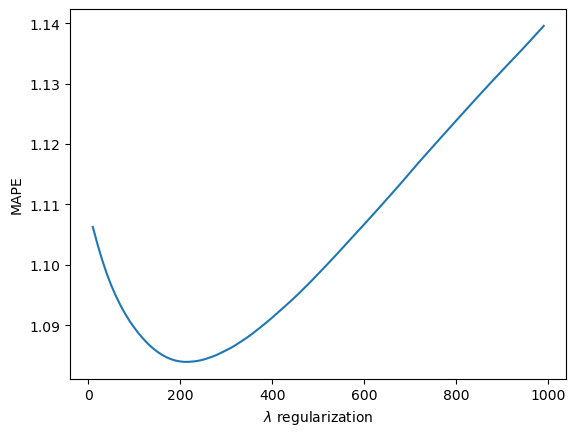

In [10]:
plt.plot(performance_trackerROP_regularization.keys(), performance_trackerROP_regularization.values())

plt.xlabel("$\lambda$ regularization")
plt.ylabel("MAPE")

plt.show()

In [11]:
performance_trackerMSI_regularization = {}

for Alpha in range(10, 1000, 10):#np.logspace(-4, 2, 50):
    for ticker in ["MSI"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
            
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 4
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue
            
            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features)
            Test_Features = scaler.transform(Test_Features)

            # Fit KNN
            MODEL = Ridge(alpha=Alpha)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
        # Save results
        performance_trackerMSI_regularization[Alpha] = np.mean(MAPEs)
        print(Alpha, np.mean(MAPEs), np.sum(MODEL.coef_ != 0))


10 1.2048982979845853 450
20 1.2007184318014332 450
30 1.1969274799042973 450
40 1.1935534477463452 450
50 1.1905342714426903 450
60 1.187855717215441 450
70 1.1855508601675289 450
80 1.1834807414573374 450
90 1.1817160785976457 450
100 1.180151578152992 450
110 1.1787890425912282 450
120 1.1775536422852784 450
130 1.1764580588552893 450
140 1.1754795543466696 450
150 1.1746262110361012 450
160 1.1739245089233292 450
170 1.1734275326518782 450
180 1.1730166074210764 450
190 1.1726631432861396 450
200 1.1723567874154184 450
210 1.1721138276026402 450
220 1.171909043392236 450
230 1.171751612440461 450
240 1.1717654368442976 450
250 1.171897483492487 450
260 1.172058179647845 450
270 1.1723252016250663 450
280 1.1726225178607501 450
290 1.1729649433324776 450
300 1.173311763494024 450
310 1.173668519581583 450
320 1.1740401541720362 450
330 1.1744478638661797 450
340 1.1748960486414677 450
350 1.1753669099122435 450
360 1.1758400550042383 450
370 1.1763121540639638 450
380 1.176788943838

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hd/lvkyz8053vg15hx2z_h9tsnh0000gn/T/ipykernel_4988/1589099792.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$ regularization")


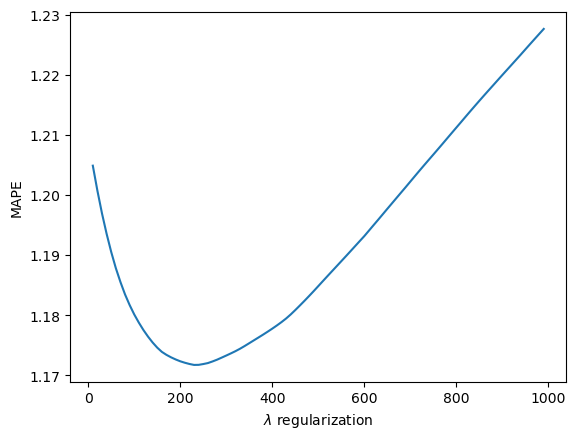

In [12]:
plt.plot(performance_trackerMSI_regularization.keys(), performance_trackerMSI_regularization.values())

plt.xlabel("$\lambda$ regularization")
plt.ylabel("MAPE")

plt.show()

In [ ]:
# argmins: 120, 210, 230
# MAPES: 1.7646582872746024, 1.7618944509177021, 1.7627612508756563 
# Dominances: 0.4485343399714957, 0.4447517429991141, 0.444066099148723

In [4]:
performance_trackerMSI_regularization = {}

for Alpha in range(200, 250):
    for ticker in ["MSI"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
            
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 4
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue
            
            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features)
            Test_Features = scaler.transform(Test_Features)

            # Fit KNN
            MODEL = Ridge(alpha=Alpha)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
        # Save results
        performance_trackerMSI_regularization[Alpha] = np.mean(MAPEs)
        print(Alpha, np.mean(MAPEs), np.sum(MODEL.coef_ != 0))


200 1.1723567874154184 450
201 1.1723289064052622 450
202 1.1723041586026068 450
203 1.1722796105980355 450
204 1.172255260909983 450
205 1.172231108069885 450
206 1.1722071506220426 450
207 1.172183387123485 450
208 1.172159816143837 450
209 1.172136436265185 450
210 1.1721138276026402 450
211 1.1720915999967871 450
212 1.1720695579342177 450
213 1.172047700049306 450
214 1.1720260249882408 450
215 1.1720053589330433 450
216 1.1719857499070523 450
217 1.1719663151216602 450
218 1.1719470532896519 450
219 1.1719279631348964 450
220 1.171909043392236 450
221 1.1718902928073704 450
222 1.1718717101367457 450
223 1.1718532941474464 450
224 1.1718350436170843 450
225 1.1718169576392867 450
226 1.171800913373668 450
227 1.1717879618382987 450
228 1.1717752016771015 450
229 1.1717630795598577 450
230 1.171751612440461 450
231 1.1717419793961035 450
232 1.1717387792492489 450
233 1.1717390934764904 450
234 1.1717398809381099 450
235 1.1717422496291907 450
236 1.1717449437949345 450
237 1.1717

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hd/lvkyz8053vg15hx2z_h9tsnh0000gn/T/ipykernel_4032/3908297301.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$ regularization")


Text(0, 0.5, 'MAPE')

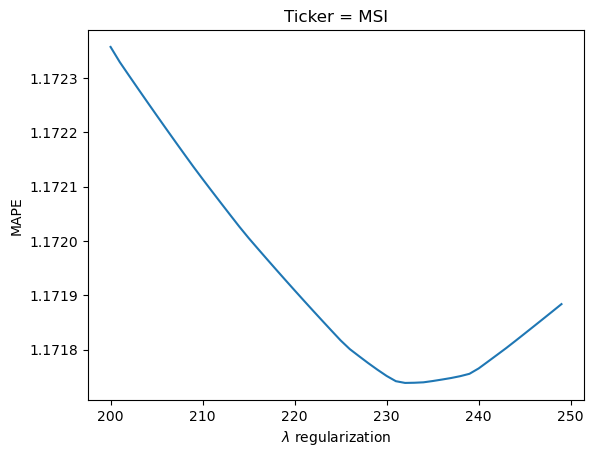

In [6]:
plt.plot(performance_trackerMSI_regularization.keys(), performance_trackerMSI_regularization.values())

plt.title("Ticker = MSI")

plt.xlabel("$\lambda$ regularization")
plt.ylabel("MAPE")

In [7]:
performance_trackerENPH_regularization_detail = {}

for Alpha in range(150, 250):
    for ticker in ["ENPH"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
            
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 4
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue
            
            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features)
            Test_Features = scaler.transform(Test_Features)

            # Fit KNN
            MODEL = Ridge(alpha=Alpha)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
        # Save results
        performance_trackerENPH_regularization_detail[Alpha] = np.mean(MAPEs)
        print(Alpha, np.mean(MAPEs), np.sum(MODEL.coef_ != 0))


150 3.618158800214505 450
151 3.6182176488373123 450
152 3.6182841443604974 450
153 3.6183527791675383 450
154 3.6184216637042974 450
155 3.6184907946485962 450
156 3.6185601687152804 450
157 3.6186322208222226 450
158 3.618705436460865 450
159 3.6187796619923724 450
160 3.618854629441858 450
161 3.61892981198306 450
162 3.619005206609755 450
163 3.6190817697635045 450
164 3.619158906813146 450
165 3.6192362427410094 450
166 3.6193137746938446 450
167 3.6193914998499523 450
168 3.6194694154187923 450
169 3.61954751864061 450
170 3.6196267468822296 450
171 3.6197122073651915 450
172 3.619802084601075 450
173 3.6198995123997713 450
174 3.620006389167319 450
175 3.62011596923294 450
176 3.6202286004658797 450
177 3.6203445109784433 450
178 3.6204625614904486 450
179 3.62058066408397 450
180 3.620699844976174 450
181 3.6208192172730156 450
182 3.6209386325598953 450
183 3.6210595850805256 450
184 3.621181546634046 450
185 3.6213076463557403 450
186 3.6214341080751344 450
187 3.621560585873

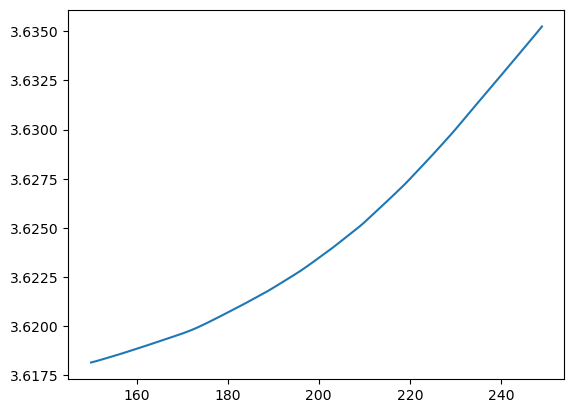

In [8]:
plt.plot(performance_trackerENPH_regularization_detail.keys(), performance_trackerENPH_regularization_detail.values())